In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df= pd.read_csv('/content/data.csv')

In [10]:
df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


In [11]:
X= df.iloc[:,0:3].values
y= df.iloc[:,-1].values

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size= 0.2, random_state= 0)

In [13]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [14]:
#Residual
y_pred= model.predict(X_test)
residual = y_test - y_pred

##Linear Regression


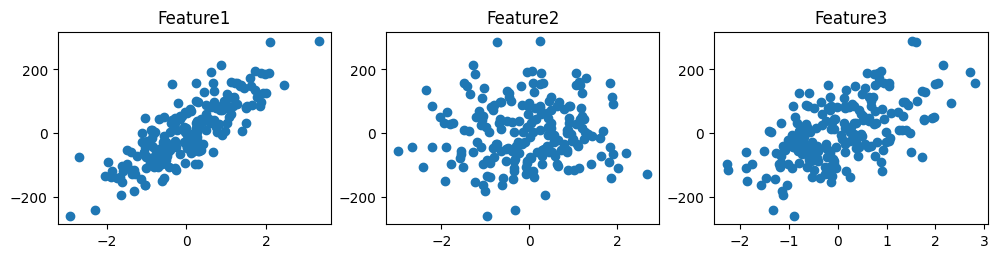

In [16]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(12, 2.5))

ax1.scatter(df['feature1'], df['target'])
ax1.set_title("Feature1")
ax2.scatter(df['feature2'], df['target'])
ax2.set_title("Feature2")
ax3.scatter(df['feature3'], df['target'])
ax3.set_title("Feature3")

plt.show()


##Multicollinearity

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = []

for i in range(X_train.shape[1]):
  vif.append(variance_inflation_factor(X_train, i))

In [19]:
pd.DataFrame({'vif': vif}, index= df.columns[0:3]).T

,feature1,feature2,feature3
vif,1.011419,1.008384,1.008333


<Axes: >

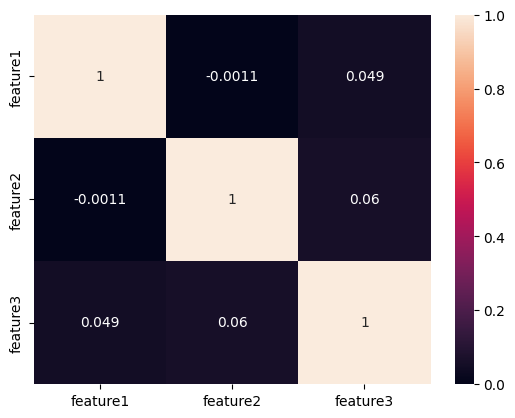

In [20]:
#Another Technique
sns.heatmap(df.iloc[:,0:3].corr(), annot= True)

##Normality of Residual

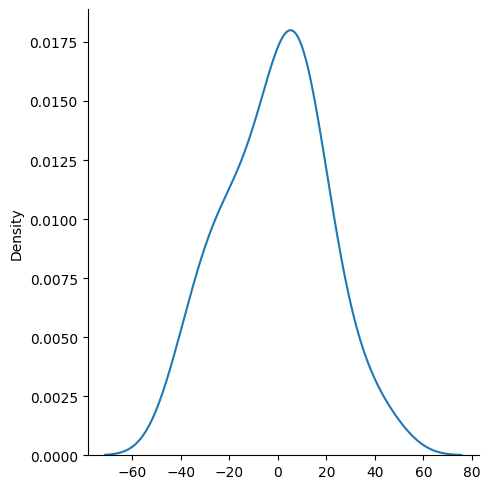

In [21]:
sns.displot (residual, kind='kde')

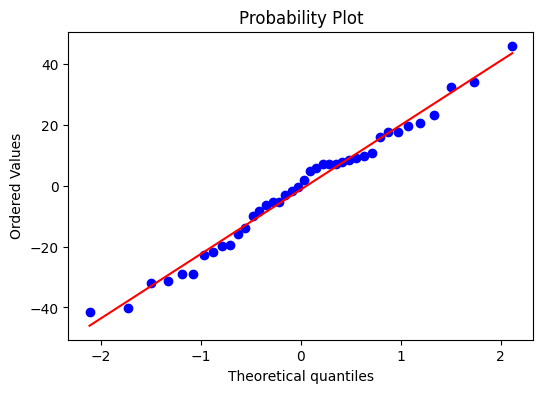

In [22]:
import scipy as sp
fig, ax= plt.subplots(figsize=(6,4))
sp.stats.probplot(residual, plot= ax, fit= True)

plt.show()

##Homoscedasticity

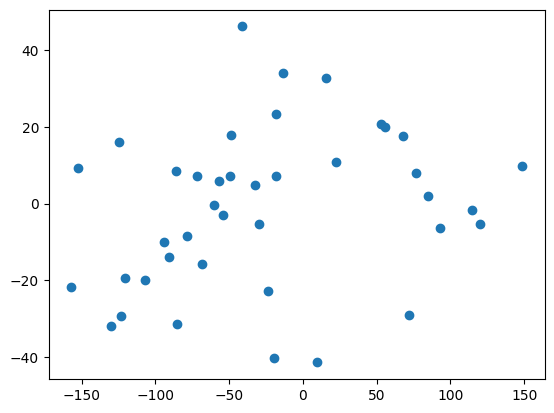

In [23]:
plt.scatter(y_pred, residual)

##Autocorerelation of Residual


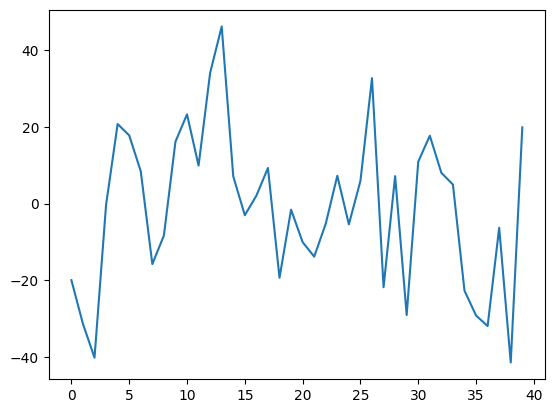

In [25]:
plt.plot(residual)
plt.show()